In [1]:
!pwd

/truejit/evaluation/compilation-latency


In [2]:
import json
import matplotlib.pyplot as plt
import scipy.stats.mstats
import numpy as np

# font
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
})

In [4]:
suites = [
    {'name': 'PolyBench',
     'benchmarks': ['2mm', '3mm', 'adi', 'atax', 'bicg',
                    'cholesky', 'correlation', 'covariance',
                    'deriche', 'doitgen', 'durbin', 'fdtd-2d', 'floyd-warshall', 'gemm', 'gemver',
                    'gesummv', 'gramschmidt', 'heat-3d', 'jacobi-1d', 'jacobi-2d',
                    'lu', 'ludcmp',
                    'mvt', 'nussinov',
                    'seidel-2d', 'symm', 'syr2k', 'syrk', 'trisolv', 'trmm'
                    ]},
    {'name': 'MiBench',
     'benchmarks': ['basicmath', 'bitcount', 'cjpeg', 'djpeg', 'stringsearch', 'blowfish-decode',
                    'blowfish-encode', 'rijndael-decode', 'rijndael-encode', 'sha', 'rawcaudio',
                    'rawdaudio', 'crc32']},
    {'name': 'Wabench',
     'benchmarks': ['bzip2', 'facedetection', 'gnuchess', 'espeak',
                    'mnist', 'snappy', 'whitedb'
                    ]},
    {'name': 'SPEC2017',
     'benchmarks': ['lbm', 'mcf',
                    'x264',
                    # 'nab',
                    # 'namd'
                    ]},
    {'name': 'JetStream',
     'benchmarks': ['gcc-loops', 'float-mm', 'hashset', 'quicksort', 'tsf']},
    {'name': 'NPB',
     'benchmarks': ['bt', 'cg', 'ep', 'ft', 'is', 'mg', 'sp']},
    {'name': 'CoreMark',
     'benchmarks': ['coremark']},
    {'name': 'GeoMean',
     'benchmarks': ['geomean']},
]
benchmarks_to_suites = {}
for suite in suites:
    for benchmark in suite['benchmarks']:
        benchmarks_to_suites[benchmark] = suite['name']
# benchmarks_to_suites

In [6]:
virtual_machines = ['truejit', 'wasmtime-cranelift', 'wasmer-single-pass', 'wasmer-cranelift', 'wasmer-llvm', 'wazero',
                    'wavm', 'graalwasm']
times = []
with open('in/virtual_machines.txt') as f:
    results = f.readlines()
    results = [result.strip() for result in results]
    results = [result for result in results if result]
    # csv
    results = [result.split(',') for result in results]

# for result in results:
#     print(result)

In [7]:
benchmarks = [result[1] for result in results[::len(virtual_machines)]]
# benchmarks

In [8]:
benchmark_to_absolute_times = {}
for i in range(0, len(results), len(virtual_machines)):
    name = results[i][1]
    times = [float(results[i + j][3]) for j in range(len(virtual_machines))]
    benchmark_to_absolute_times[name] = times
# benchmark_to_absolute_times

In [9]:
benchmark_to_times = {}
benchmark_to_speedups = {}
for i in range(0, len(results), len(virtual_machines)):
    name = results[i][1]
    times = [float(results[i + j][3]) for j in range(len(virtual_machines))]
    # replace -1s with max time
    max_time = max([time for time in times if time != -1])
    times = [max_time if time == -1 else time for time in times]
    # normalize
    times = [time / times[0] for time in times]
    speedups = [1 / time for time in times]
    benchmark_to_times[name] = times
    benchmark_to_speedups[name] = speedups
# benchmark_to_times

In [10]:
# geomean = [scipy.stats.mstats.gmean([benchmark_to_speedups[benchmark][vm] for benchmark in benchmarks], weights=[sum(benchmark_to_absolute_times[benchmark]) / len(benchmark_to_absolute_times[benchmark]) for benchmark in benchmarks]) for vm in range(len(virtual_machines))]
geomean = [scipy.stats.mstats.gmean([benchmark_to_speedups[benchmark][vm] for benchmark in benchmarks],
                                    weights=[min(benchmark_to_absolute_times[benchmark]) for benchmark in benchmarks])
           for vm in range(len(virtual_machines))]
benchmarks.append('geomean')
benchmark_to_times['geomean'] = geomean
list(zip(virtual_machines, geomean))

[('truejit', 1.0),
 ('wasmtime-cranelift', 1.0140353613696735),
 ('wasmer-single-pass', 0.574881181948516),
 ('wasmer-cranelift', 0.9794275893709069),
 ('wasmer-llvm', 1.0209915606804307),
 ('wazero', 0.7458267394006513),
 ('wavm', 1.0178971474017606),
 ('graalwasm', 0.6557240544025819)]

KeyError: 'hashset'

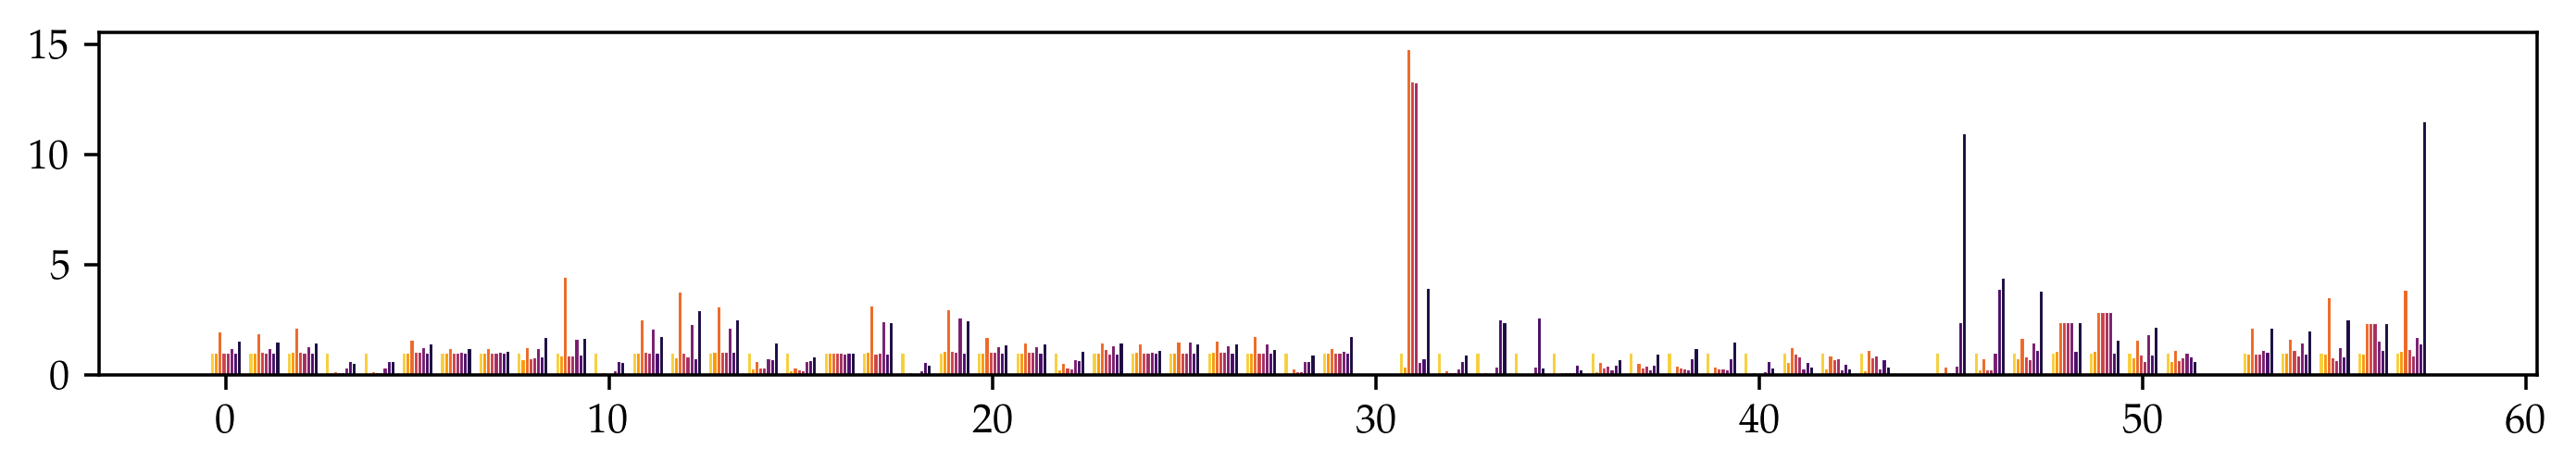

In [11]:
import matplotlib.pyplot as plt
import bokeh.palettes

colors = bokeh.palettes.inferno(len(virtual_machines) + 2)[1:-1]
colors = colors[::-1]

# create a figure with a single subplot
width = len(benchmarks) / 6.5
height = 1.5

bar_width = .1

SPACE_BETWEEN_SUITES = 1

fig, ax = plt.subplots(figsize=(width, height), dpi=320)

all_x_labels = []
all_x_labels_positions = []
x_start = 0
x_start -= bar_width * (len(virtual_machines) - 1) / 2
for suite in range(len(suites)):
    benchmark_x_labels = suites[suite]['benchmarks']
    benchmark_x_labels_positions = np.arange(len(benchmark_x_labels), dtype=float)
    benchmark_x_labels_positions += x_start + bar_width * (len(virtual_machines) - 1) / 2
    all_x_labels_positions += benchmark_x_labels_positions.tolist()
    xs = np.arange(len(benchmark_x_labels), dtype=float)
    xs += x_start
    for vm in range(len(virtual_machines)):
        ys = [benchmark_to_times[benchmark][vm] for benchmark in benchmark_x_labels]
        ax.bar(xs, ys, bar_width, color=colors[vm], edgecolor='white', linewidth=0.25)
        xs += bar_width
    x_start += len(benchmark_x_labels) + SPACE_BETWEEN_SUITES
    all_x_labels += benchmark_x_labels

# xlabel
ax.set_xticks(all_x_labels_positions, all_x_labels, rotation=45, fontsize=6, ha='right', rotation_mode='anchor',
              va='top', y=0.1)

# remove xticks
ax.tick_params(axis='x', which='both', bottom=False, top=False)

# x is log
ax.set_yscale('log')

y_ticks = [0.1, 0.1, 1, 10, 20]
ax.set_ylim(y_ticks[0], y_ticks[-1])
ax.set_yticks(y_ticks[1:-1], [f'{tick}' for tick in y_ticks[1:-1]], fontsize=6, x=0.005)

# a horizontal line at y=1
ax.axhline(y=1, color='black', linewidth=0.25, linestyle='--', clip_on=False, alpha=0.5)

ax.set_ylabel('Speedup', fontsize=6)

plt.margins(x=0.002, y=0.1)

# grid major y
# ax.set_axisbelow(True)

# ax.grid(which='major', axis='y', linestyle='--', linewidth=0.25, color='black', zorder=-100)

# labels: =virtual_machines[vm]
for vm in range(len(virtual_machines)):
    ax.bar(0, 0, color=colors[vm], label=virtual_machines[vm], edgecolor='black', linewidth=0.25)

# legend is on top middle of the plot one row above the plot
plt.legend(loc='upper center',
           bbox_to_anchor=(0.5, 1.05),
           ncol=len(virtual_machines),
           fontsize=5.5,
           frameon=False,
           edgecolor='black')

# make ticks thinner
ax.tick_params(which='both', width=0.25)

plt.tight_layout()

plt.savefig('out/virtual_machines.latencies.pdf', bbox_inches='tight', pad_inches=0.0, dpi=320, transparent=True,
            format='pdf')

plt.show()

In [ ]:
list(zip(virtual_machines, geomean))

In [ ]:
# plot speedups geomean
import matplotlib.pyplot as plt
import bokeh.palettes

colors = bokeh.palettes.inferno(len(virtual_machines) + 2)[1:-1]
colors = colors[::-1]

# create a figure with a single subplot
fig, ax = plt.subplots(figsize=(2.5, 1.5), dpi=320)

# data
data = list(zip(virtual_machines, geomean))
# sort by speedup
data = sorted(data, key=lambda x: x[1], reverse=True)
# plot
xs = np.arange(len(data))
ys = [speedup for _, speedup in data]
ax.bar(xs, ys, color=colors, edgecolor='black', linewidth=0.25)

# write the value on top of the bar
for i, y in enumerate(ys):
    ax.text(i, y, f'$\\times{y:.2f}$', ha='center', va='bottom', fontsize=5)

# y limit
plt.ylim(0, 2)

# y is log
# plt.yscale('log')

# remove x ticks
plt.xticks([])
# remove x spine
# remove y ticks
plt.yticks([])
# remove y minor ticks
plt.minorticks_off()

plt.xticks(xs, [f'{vm}' for vm, _ in data], fontsize=5, rotation=45, ha='right', rotation_mode='anchor', va='top')

plt.ylabel('Speedup', fontsize=6)

plt.tight_layout()

plt.savefig('out/virtual_machines.geomean.latencies.pdf', bbox_inches='tight', pad_inches=0.0, dpi=320,
            transparent=True, format='pdf')

plt.show()

In [ ]:
compilation_modes = ['RemoteJIT', 'TrueJIT']
network_latencies = ['0ms', '1ms', '2ms', '5ms', '10ms']
schemes = [f'{compilation_mode} ({network_latency})' for compilation_mode in compilation_modes for network_latency in
           network_latencies]
# schemes

In [12]:
with open('in/compilation_latencies_comparison.network_latency.txt') as f:
    results = f.readlines()
    results = [result.strip() for result in results]
    results = [result for result in results if result]
    results = [json.loads(result) for result in results]
benchmarks = [result['Application'] for result in results[::len(schemes)]]
# benchmarks

In [13]:
benchmarks_to_latencies = {}
for i in range(0, len(results), len(schemes)):
    name = results[i]['Application']
    latencies = [results[i + j]['Latencies'] for j in range(len(schemes))]
    # avg latency
    latencies = [np.mean(latency) for latency in latencies]
    # normalize latency
    latencies = [latency / latencies[0] for latency in latencies]
    benchmarks_to_latencies[name] = latencies
# benchmarks_to_latencies

In [14]:
geomean = [np.mean([benchmarks_to_latencies[benchmark][scheme] for benchmark in benchmarks]) for scheme in
           range(len(schemes))]
benchmarks.append('geomean')
benchmarks_to_latencies['geomean'] = geomean
geomean

[1.0,
 4.165786964728988,
 6.688874295516875,
 14.012303975912113,
 26.084272721067514,
 0.1393877165232458,
 0.2759906471049532,
 0.41981215615744993,
 0.8288853639010809,
 1.5108469517639245]

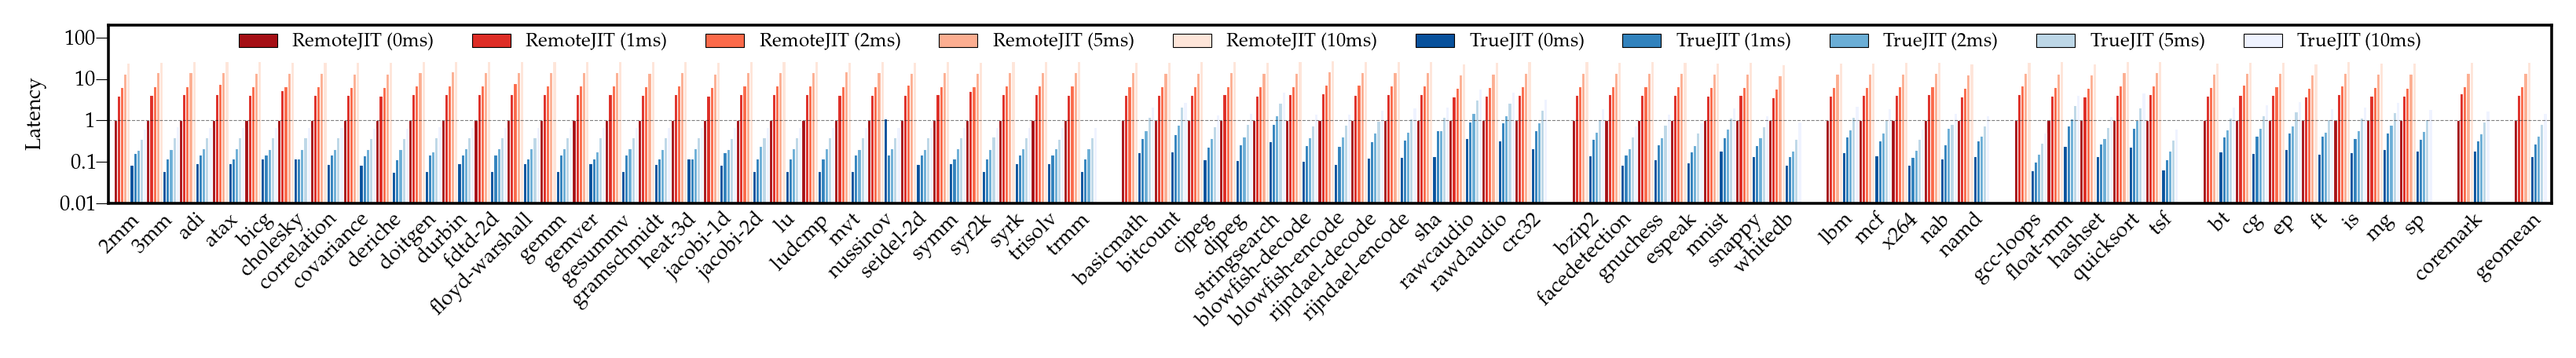

In [15]:
import matplotlib.pyplot as plt
import bokeh.palettes

# colors = bokeh.palettes.magma(len(schemes))
colors = bokeh.palettes.Reds[len(schemes) // 2] + bokeh.palettes.Blues[len(schemes) // 2]
# colors = colors[::-1]

# create a figure with a single subplot
width = len(benchmarks) / 6.5
height = 1.5

bar_width = .1

SPACE_BETWEEN_SUITES = .75

fig, ax = plt.subplots(figsize=(width, height), dpi=320)

all_x_labels = []
all_x_labels_positions = []
x_start = 0
x_start -= bar_width * (len(schemes) - 1) / 2

for suite in range(len(suites)):
    benchmark_x_labels = suites[suite]['benchmarks']
    benchmark_x_labels_positions = np.arange(len(benchmark_x_labels), dtype=float)
    benchmark_x_labels_positions += x_start + bar_width * (len(schemes) - 1) / 2
    all_x_labels_positions += benchmark_x_labels_positions.tolist()
    xs = np.arange(len(benchmark_x_labels), dtype=float)
    xs += x_start
    for scheme in range(len(schemes)):
        ys = [benchmarks_to_latencies[benchmark][scheme] for benchmark in benchmark_x_labels]
        ax.bar(xs, ys, bar_width, color=colors[scheme], edgecolor='white', linewidth=0.25)
        xs += bar_width
    x_start += len(benchmark_x_labels) + SPACE_BETWEEN_SUITES
    all_x_labels += benchmark_x_labels

# xlabel
ax.set_xticks(all_x_labels_positions, all_x_labels, rotation=45, fontsize=6, ha='right', rotation_mode='anchor',
              va='top', y=0.1)

# remove xticks
ax.tick_params(axis='x', which='both', bottom=False, top=False)

# x is log
ax.set_yscale('log')

y_ticks = [0.01, 0.01, 0.1, 1, 10, 100, 200]
ax.set_ylim(y_ticks[0], y_ticks[-1])
ax.set_yticks(y_ticks[1:-1], [f'{tick}' for tick in y_ticks[1:-1]], fontsize=6, x=0.005)

# a horizontal line at y=1
ax.axhline(y=1, color='black', linewidth=0.25, linestyle='--', clip_on=False, alpha=0.5)

ax.set_ylabel('Latency', fontsize=6)

plt.margins(x=0.002, y=0.1)

# grid major y
# ax.set_axisbelow(True)

# ax.grid(which='major', axis='y', linestyle='--', linewidth=0.25, color='black', zorder=-100)

# labels: =schemes[scheme]
for scheme in range(len(schemes)):
    ax.bar(0, 0, color=colors[scheme], label=schemes[scheme], edgecolor='black', linewidth=0.25)

# legend is on top middle of the plot one row above the plot
plt.legend(loc='upper center',
           bbox_to_anchor=(0.5, 1.05),
           ncol=len(schemes),
           fontsize=5.5,
           frameon=False,
           edgecolor='black')

# make ticks thinner
ax.tick_params(which='both', width=0.25)

plt.tight_layout()

plt.savefig('out/compilation_latencies_comparison.network_latency.pdf', bbox_inches='tight', pad_inches=0.0, dpi=320,
            transparent=True,
            format='pdf')

plt.show()

In [5]:
schemes = [f'{i} Gram LSTM' for i in [1, 2, 3, 4, 5, 10, 20, 50, 100, 200]]

In [6]:
with open('in/compilation_speedups_comparison.prediction_depth.txt') as f:
    results = f.readlines()
    results = [result.strip() for result in results]
    results = [result for result in results if result]
    results = [json.loads(result) for result in results]
benchmarks = [result['Application'] for result in results[::len(schemes)]]
# benchmarks, len(benchmarks)

In [7]:
benchmarks_to_speedups = {}
for i in range(0, len(results), len(schemes)):
    name = results[i]['Application']
    latencies = [results[i + j]['Latencies'] for j in range(len(schemes))]
    # avg latency
    latencies = [np.mean(latency) for latency in latencies]
    # normalize latency
    speedups = [latencies[0] / latency for latency in latencies]
    benchmarks_to_speedups[name] = speedups
# benchmarks_to_speedups

In [8]:
# add geomean to GeoMean
geomean = [np.mean([benchmarks_to_speedups[benchmark][scheme] for benchmark in benchmarks]) for scheme in
           range(len(schemes))]
benchmarks.append('geomean')
benchmarks_to_speedups['geomean'] = geomean
geomean

[1.0,
 1.1394963407452114,
 1.2963998987666587,
 1.476114755350121,
 1.567795794075819,
 1.8704351181198862,
 2.4165519211582716,
 2.6549269924697367,
 2.6727176599814952,
 2.674156826939028]

KeyError: 'hashset'

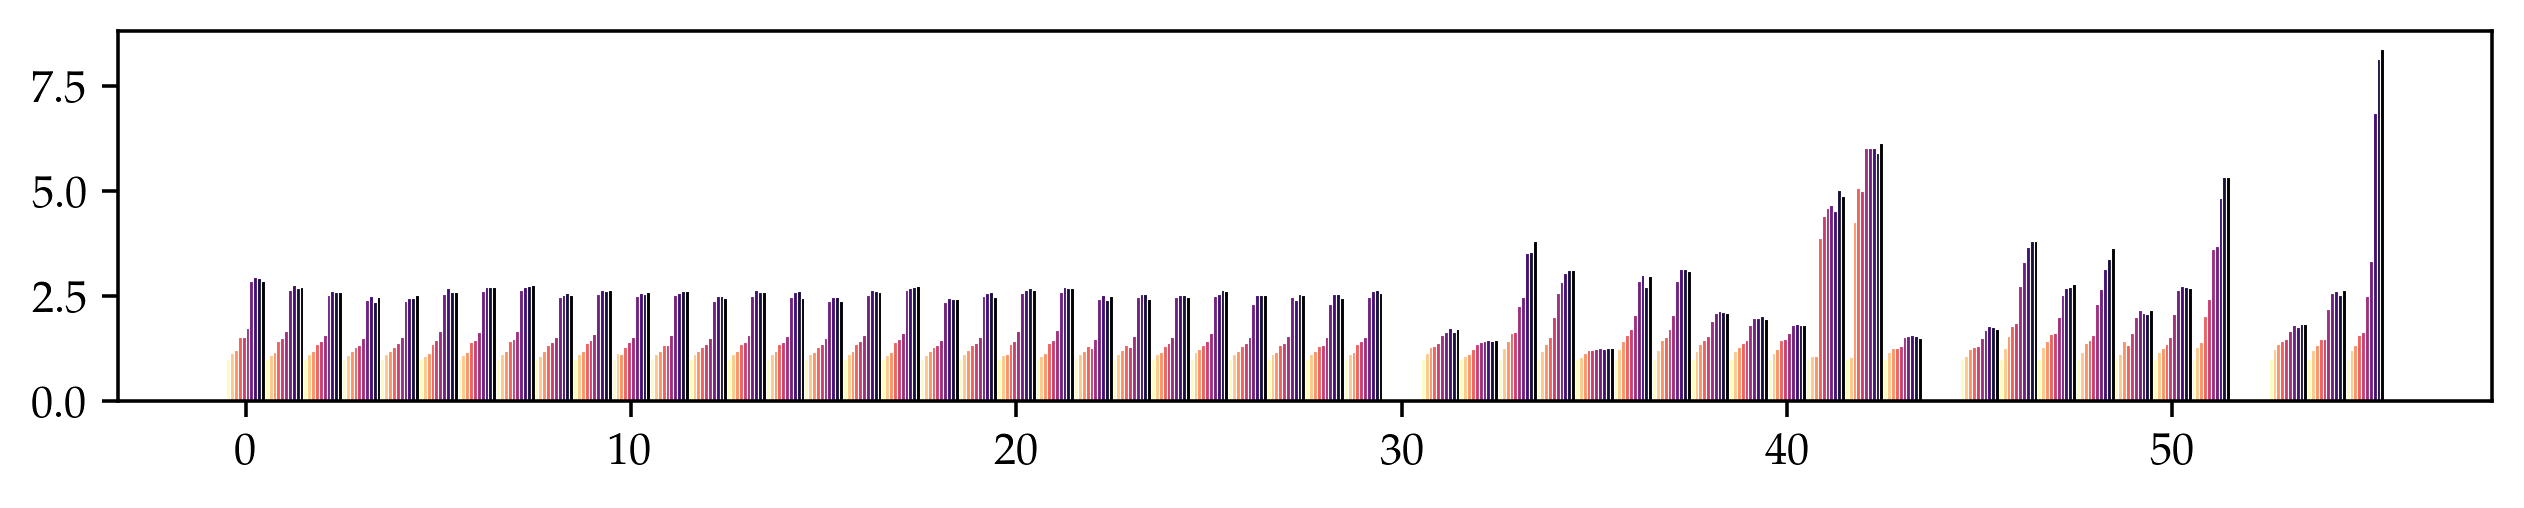

In [9]:
import matplotlib.pyplot as plt
import bokeh.palettes

colors = bokeh.palettes.magma(len(schemes))
colors = colors[::-1]

# create a figure with a single subplot
width = len(benchmarks) / 7
height = 1.5

bar_width = .1

SPACE_BETWEEN_SUITES = 1

fig, ax = plt.subplots(figsize=(width, height), dpi=320)

all_x_labels = []
all_x_labels_positions = []
x_start = 0
x_start -= bar_width * (len(schemes) - 1) / 2
for suite in range(len(suites)):
    benchmark_x_labels = suites[suite]['benchmarks']
    benchmark_x_labels_positions = np.arange(len(benchmark_x_labels), dtype=float)
    benchmark_x_labels_positions += x_start + bar_width * (len(schemes) - 1) / 2
    all_x_labels_positions += benchmark_x_labels_positions.tolist()
    xs = np.arange(len(benchmark_x_labels), dtype=float)
    xs += x_start
    for scheme in range(len(schemes)):
        ys = [benchmarks_to_speedups[benchmark][scheme] for benchmark in benchmark_x_labels]
        ax.bar(xs, ys, bar_width, color=colors[scheme], edgecolor='white', linewidth=0.25)
        xs += bar_width
    x_start += len(benchmark_x_labels) + SPACE_BETWEEN_SUITES
    all_x_labels += benchmark_x_labels

# xlabel
ax.set_xticks(all_x_labels_positions, all_x_labels, rotation=45, fontsize=6, ha='right', rotation_mode='anchor',
              va='top', y=0.1)

# remove xticks
ax.tick_params(axis='x', which='both', bottom=False, top=False)

# x is log
# ax.set_yscale('log')

y_ticks = [0] + list(range(0, 8 + 1)) + [8]
ax.set_ylim(y_ticks[0], y_ticks[-1])
ax.set_yticks(y_ticks[1:-1], [f'$\\times{tick}$' for tick in y_ticks[1:-1]], fontsize=6, x=0.005)

# a horizontal line at y=1
ax.axhline(y=1, color='black', linewidth=0.25, linestyle='--', clip_on=False, alpha=0.5)

ax.set_ylabel('Speedup', fontsize=6)

plt.margins(x=0.002, y=0.1)

# grid major y
# ax.set_axisbelow(True)
# ax.grid(which='major', axis='y', linestyle='--', linewidth=0.25, color='black', zorder=-100)

# labels: =schemes[scheme]
for scheme in range(len(schemes)):
    ax.bar(0, 0, color=colors[scheme], label=schemes[scheme], edgecolor='black', linewidth=0.25)

# legend is on top middle of the plot one row above the plot
plt.legend(loc='upper center',
           bbox_to_anchor=(0.5, 1.05),
           ncol=len(schemes),
           fontsize=5,
           frameon=False,
           edgecolor='black')

# make ticks thinner
ax.tick_params(which='both', width=0.25)

plt.tight_layout()

plt.savefig('out/compilation_speedups_comparison.prediction_depths.pdf', bbox_inches='tight', pad_inches=0.0, dpi=320,
            transparent=True,
            format='pdf')

plt.show()

In [43]:
schemes = ['Local JIT', 'Remote JIT', 'TrueJIT']
repetitions = 3

In [48]:
with open('in/compilation_speedups_comparison.key_results.txt') as f:
    results = f.readlines()
    results = [result.strip() for result in results]
    results = [result for result in results if result]
    results = [json.loads(result) for result in results]
benchmarks = [result['Application'] for result in results[::len(schemes) * repetitions]]
# benchmarks, len(benchmarks)
len(benchmarks)

68

In [50]:
absolute_benchmarks_latencies = {}
for b, benchmark in enumerate(benchmarks):
    schemes_latencies = {}
    for s, scheme in enumerate(schemes):
        repetitions_latencies = []
        for r in range(repetitions):
            record = results[b * len(schemes) * repetitions + s * repetitions + r]
            assert record['Application'] == benchmark
            repetitions_latencies.append(np.mean(record['Latencies']))
        repetitions_latencies = repetitions_latencies[1:]  # remove the first one
        latencies = np.mean(repetitions_latencies)
        schemes_latencies[scheme] = latencies
    absolute_benchmarks_latencies[benchmarks[b]] = schemes_latencies
absolute_benchmarks_latencies

{'2mm': {'Local JIT': 732.0, 'Remote JIT': 442.125, 'TrueJIT': 68.205},
 '3mm': {'Local JIT': 771.0, 'Remote JIT': 430.99, 'TrueJIT': 51.57},
 'adi': {'Local JIT': 784.5,
  'Remote JIT': 418.505,
  'TrueJIT': 59.730000000000004},
 'atax': {'Local JIT': 668.5, 'Remote JIT': 367.135, 'TrueJIT': 56.65},
 'bicg': {'Local JIT': 757.5,
  'Remote JIT': 377.16999999999996,
  'TrueJIT': 49.989999999999995},
 'cholesky': {'Local JIT': 779.5, 'Remote JIT': 441.975, 'TrueJIT': 51.86},
 'correlation': {'Local JIT': 707.0,
  'Remote JIT': 448.42499999999995,
  'TrueJIT': 60.04},
 'covariance': {'Local JIT': 702.5, 'Remote JIT': 420.47, 'TrueJIT': 56.43},
 'deriche': {'Local JIT': 683.5,
  'Remote JIT': 395.405,
  'TrueJIT': 43.114999999999995},
 'doitgen': {'Local JIT': 706.0,
  'Remote JIT': 406.96500000000003,
  'TrueJIT': 50.575},
 'durbin': {'Local JIT': 766.0, 'Remote JIT': 382.77, 'TrueJIT': 50.405},
 'fdtd-2d': {'Local JIT': 847.5, 'Remote JIT': 419.605, 'TrueJIT': 61.775},
 'floyd-warshall':

In [47]:
relative_benchmarks_latencies = {}
for b in range(len(benchmarks)):
    latencies = absolute_benchmarks_latencies[benchmarks[b]]
    relative_latencies = [latency / latencies[0] for latency in latencies]
    relative_benchmarks_latencies[benchmarks[b]] = relative_latencies
relative_benchmarks_latencies

KeyError: 0

In [10]:
relative_benchmarks_speedups = []
for b in range(len(benchmarks)):
    latencies = relative_benchmarks_latencies[b]
    speedups = [1 / latency for latency in latencies]
    relative_benchmarks_speedups.append(speedups)
relative_benchmarks_speedups

[[1.0, 1.6556403731976252, 10.732351000659776],
 [1.0, 1.7889046149562635, 14.950552646887724],
 [1.0, 1.8745295755128375, 13.134103465595176],
 [1.0, 1.8208560883598675, 11.800529567519858],
 [1.0, 2.0083781849033597, 15.153030606121225],
 [1.0, 1.763674415973754, 15.030852294639413],
 [1.0, 1.5766293137090932, 11.775483011325782],
 [1.0, 1.6707493994815326, 12.449051922736134],
 [1.0, 1.728607377246115, 15.852951409022385],
 [1.0, 1.7347929183099282, 13.959466139396936],
 [1.0, 2.0012017660736214, 15.196905068941572],
 [1.0, 2.019756675921402, 13.719142047753946],
 [1.0, 1.8855202037860246, 12.497930806157921],
 [1.0, 2.1139109755218715, 15.61945331913383],
 [1.0, 1.7510861502596164, 12.71153846153846],
 [1.0, 2.1222208177081137, 15.12815378454145],
 [1.0, 1.8107151733197626, 14.043139054612208],
 [1.0, 1.6631338659709767, 12.558262246064551],
 [1.0, 1.7921339271341954, 12.340661370774063],
 [1.0, 1.740303191420383, 12.224448897795591],
 [1.0, 2.045193412485638, 14.673017036087195],


In [11]:
import scipy.stats.mstats

geomeans = []
for s in range(len(schemes)):
    gmean = scipy.stats.mstats.gmean([relative_benchmarks_speedups[b][s] for b in range(len(benchmarks))],
                                     weights=[absolute_benchmarks_latencies[b][0] for b in range(len(benchmarks))])
    geomeans.append(gmean)
geomeans

[1.0, 1.2150678308020277, 5.903159940654605]

In [12]:
benchmarks.append('geomean')
relative_benchmarks_speedups.append(geomeans)

2mm
3mm
adi
atax
bicg
cholesky
correlation
covariance
deriche
doitgen
durbin
fdtd-2d
floyd-warshall
gemm
gemver
gesummv
gramschmidt
heat-3d
jacobi-1d
jacobi-2d
lu
ludcmp
mvt
nussinov
seidel-2d
symm
syr2k
syrk
trisolv
trmm
basicmath
bitcount
cjpeg
djpeg
stringsearch
blowfish-decode
blowfish-encode
rijndael-decode
rijndael-encode
sha
rawcaudio
rawdaudio
crc32
bzip2
facedetection
gnuchess
espeak
mnist
snappy
whitedb
lbm
mcf
x264
nab
namd
gcc-loops
float-mm
hashset
quicksort
tsf
bt
cg
ep
ft
is
mg
sp
coremark
geomean


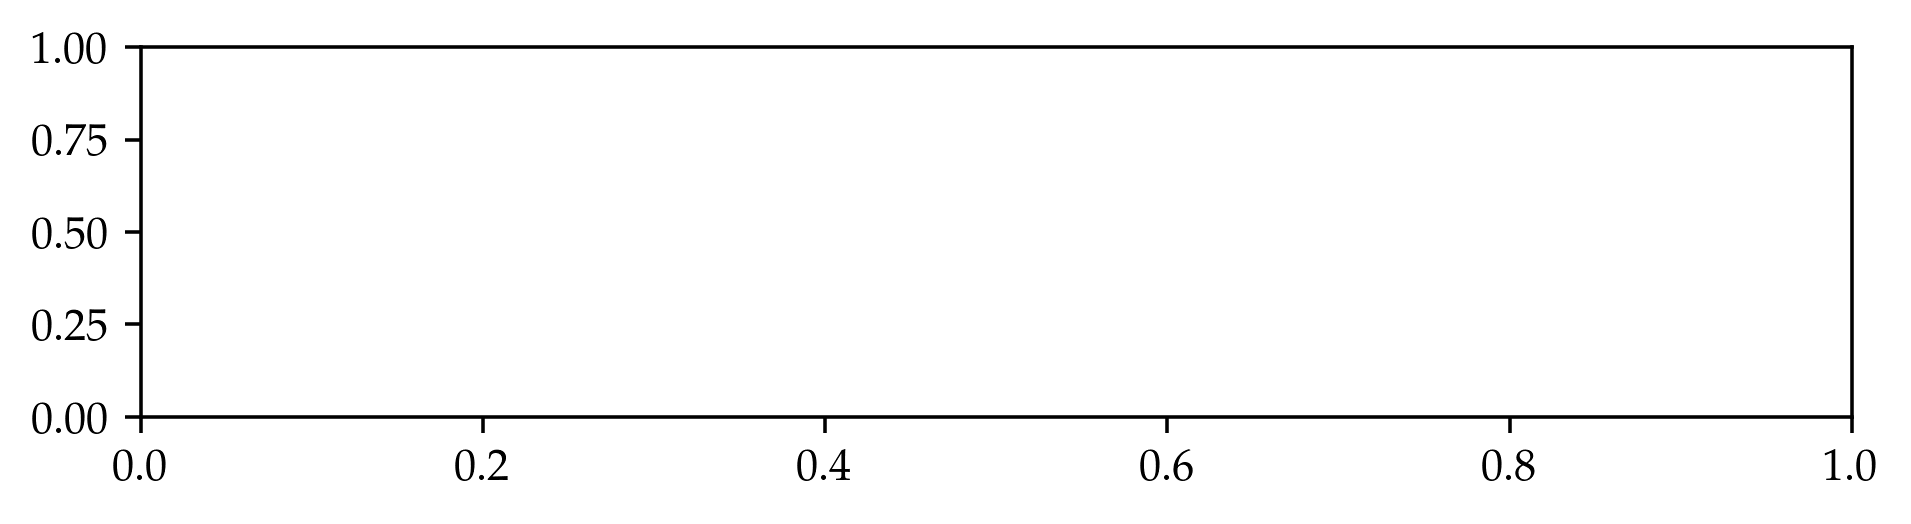

In [41]:
import matplotlib.pyplot as plt
import bokeh.palettes

colors = bokeh.palettes.Blues[len(schemes)]
colors = colors[::-1]

# create a figure with a single subplot
width = len(benchmarks) / 10
height = 1.5

bar_width = .9

SPACE_BETWEEN_SUITES = 1

fig, ax = plt.subplots(figsize=(width, height), dpi=320)

vals = [1, 2, 1.5]

x_offset = 0
for suite in suites:
    for b in range(len(suite['benchmarks'])):
        print(suite['benchmarks'][b])
    x_offset += SPACE_BETWEEN_SUITES

# # plot geomeans
# for j in range(10):
#     for opt, val in enumerate(vals):
#         x = j - bar_width / len(vals) + opt * bar_width / len(vals)
#         ax.bar(x, geomeans[opt], bar_width / len(vals), color=colors[opt], edgecolor='white', linewidth=0.25)


# x labels is all xs
# ax.set_xticks(xs, [f'{benchmark}' for benchmark in benchmarks])

plt.show()

In [85]:
benchmarks_to_speedups = {}
for i in range(0, len(results), len(schemes)):
    name = results[i]['Application']
    latencies = [results[i + j]['Latencies'] for j in range(len(schemes))]
    # assert they have the same name
    assert all([name == results[i + j]['Application'] for j in range(len(schemes))])
    # avg latency
    latencies = [np.mean(latency) for latency in latencies]
    # normalize latency
    speedups = [latencies[0] / latency for latency in latencies]
    benchmarks_to_speedups[name] = speedups
# benchmarks_to_speedups

In [84]:
# add geomean to GeoMean
geomean = [np.mean([benchmarks_to_speedups[benchmark][scheme] for benchmark in benchmarks]) for scheme in
           range(len(schemes))]
benchmarks.append('geomean')
benchmarks_to_speedups['geomean'] = geomean
# geomean

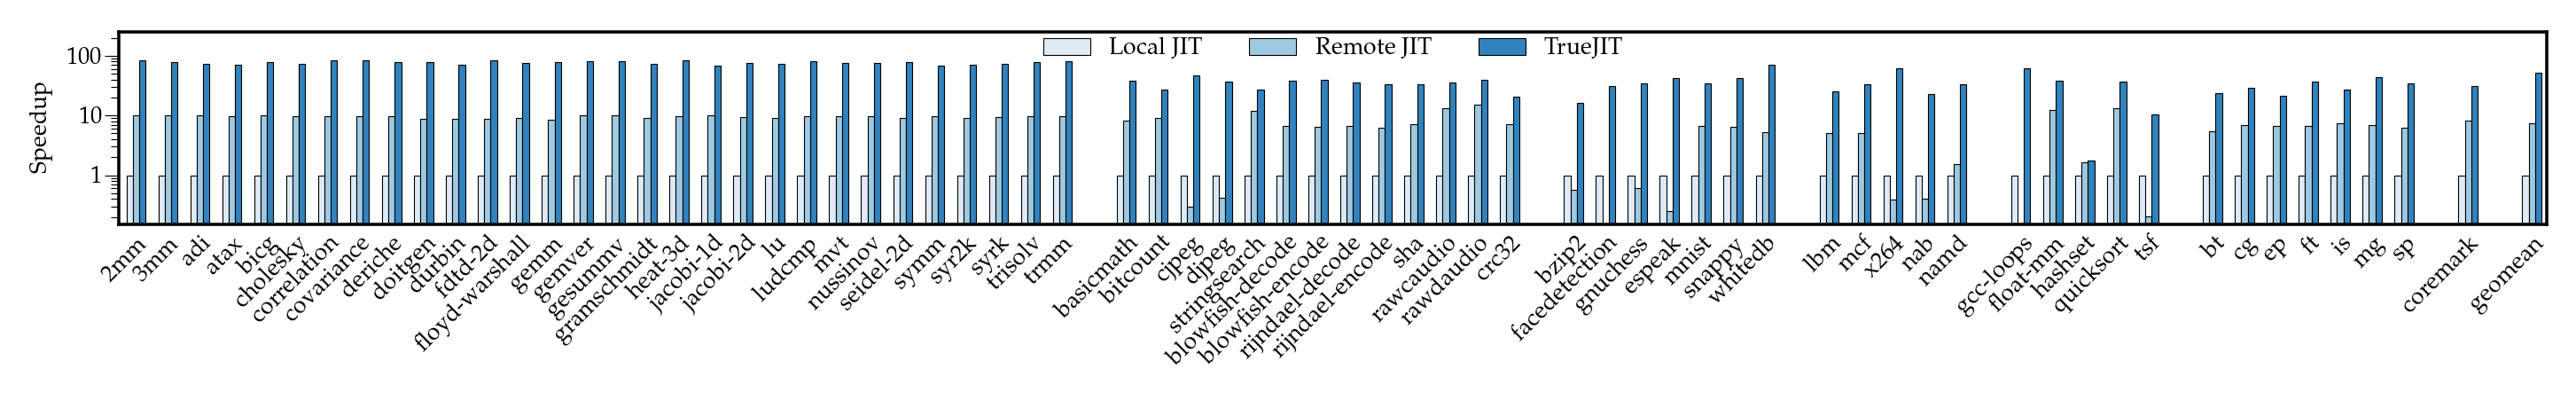

In [25]:
import matplotlib.pyplot as plt
import bokeh.palettes

colors = bokeh.palettes.Blues[len(schemes)]
colors = colors[::-1]

# create a figure with a single subplot
width = len(benchmarks) / 10
height = 1.5

bar_width = .2

SPACE_BETWEEN_SUITES = 1

fig, ax = plt.subplots(figsize=(width, height), dpi=320)

all_x_labels = []
all_x_labels_positions = []
x_start = 0
x_start -= bar_width * (len(schemes) - 1) / 2
for suite in range(len(suites)):
    benchmark_x_labels = suites[suite]['benchmarks']
    benchmark_x_labels_positions = np.arange(len(benchmark_x_labels), dtype=float)
    benchmark_x_labels_positions += x_start + bar_width * (len(schemes) - 1) / 2
    all_x_labels_positions += benchmark_x_labels_positions.tolist()
    xs = np.arange(len(benchmark_x_labels), dtype=float)
    xs += x_start
    for scheme in range(len(schemes)):
        ys = [benchmarks_to_speedups[benchmark][scheme] for benchmark in benchmark_x_labels]
        ax.bar(xs, ys, bar_width, color=colors[scheme], edgecolor='black', linewidth=0.25)
        xs += bar_width
    x_start += len(benchmark_x_labels) + SPACE_BETWEEN_SUITES
    all_x_labels += benchmark_x_labels

# xlabel
ax.set_xticks(all_x_labels_positions, all_x_labels, rotation=45, fontsize=6, ha='right', rotation_mode='anchor',
              va='top', y=0.1)

# remove xticks
ax.tick_params(axis='x', which='both', bottom=False, top=False)

# x is log
ax.set_yscale('log')

y_ticks = [.15, 1, 10, 100, 250]
ax.set_ylim(y_ticks[0], y_ticks[-1])
ax.set_yticks(y_ticks[1:-1], [f'{tick}' for tick in y_ticks[1:-1]], fontsize=6, x=0.005)

ax.set_ylabel('Speedup', fontsize=6)

plt.margins(x=0.002, y=0.1)

# grid major y
# ax.set_axisbelow(True)
# ax.grid(which='major', axis='y', linestyle='--', linewidth=0.25, color='black', zorder=-100)

# labels: =schemes[scheme]
for scheme in range(len(schemes)):
    ax.bar(0, 0, color=colors[scheme], label=schemes[scheme], edgecolor='black', linewidth=0.25)

# legend is on top middle of the plot one row above the plot
plt.legend(loc='upper center',
           bbox_to_anchor=(0.5, 1.08),
           ncol=len(schemes),
           fontsize=6,
           frameon=False,
           edgecolor='black')

# make ticks thinner
ax.tick_params(which='both', width=0.25)

plt.tight_layout()

plt.savefig('out/compilation_speedups_comparison.key_results.pdf', bbox_inches='tight', pad_inches=0.0, dpi=320,
            transparent=True,
            format='pdf')

plt.show()

In [26]:
schemes = ['No Cache, No Prediction', 'With Cache, No Prediction', 'With Cache, With Prediction']

In [27]:
with open('in/compilation_latencies_comparison.cache_and_prediction.txt') as f:
    results = f.readlines()
    results = [result.strip() for result in results]
    results = [result for result in results if result]
    results = [json.loads(result) for result in results]
benchmarks = [result['Application'] for result in results[::len(schemes)]]
# benchmarks, len(benchmarks)

In [28]:
benchmarks_to_speedups = {}
for i in range(0, len(results), len(schemes)):
    name = results[i]['Application']
    latencies = [results[i + j]['Latencies'] for j in range(len(schemes))]
    # avg latency
    latencies = [np.mean(latency) for latency in latencies]
    # normalize latency
    speedups = [latencies[0] / latency for latency in latencies]
    benchmarks_to_speedups[name] = speedups
# benchmarks_to_speedups

In [29]:
# add geomean to GeoMean
geomean = [np.mean([benchmarks_to_speedups[benchmark][scheme] for benchmark in benchmarks]) for scheme in
           range(len(schemes))]
benchmarks.append('geomean')
benchmarks_to_speedups['geomean'] = geomean
geomean

[1.0, 18.892724471089796, 132.62937339445955]

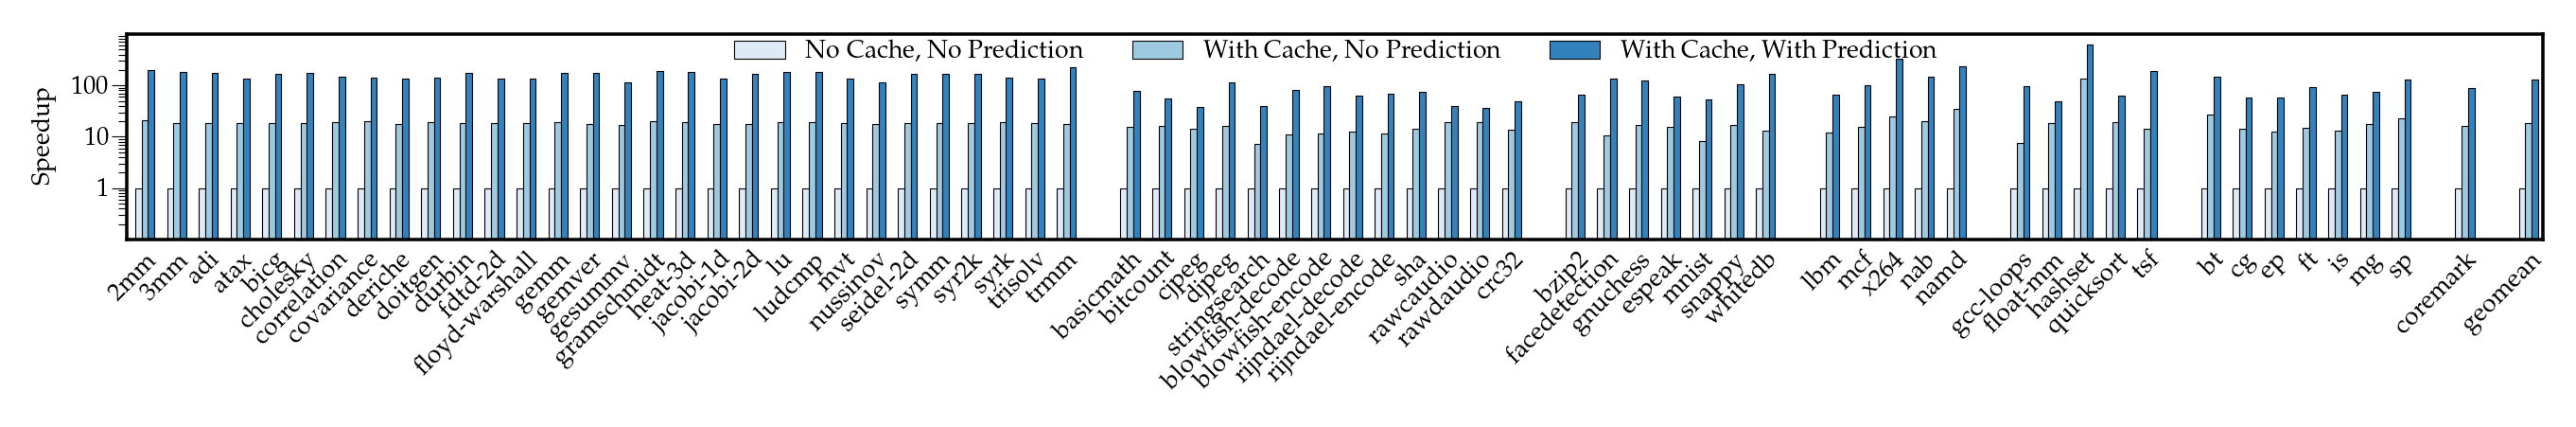

In [30]:
import matplotlib.pyplot as plt
import bokeh.palettes

colors = bokeh.palettes.Blues[len(schemes)]
colors = colors[::-1]

# create a figure with a single subplot
width = len(benchmarks) / 8
height = 1.5

bar_width = .2

SPACE_BETWEEN_SUITES = 1

fig, ax = plt.subplots(figsize=(width, height), dpi=320)

all_x_labels = []
all_x_labels_positions = []
x_start = 0
x_start -= bar_width * (len(schemes) - 1) / 2

for suite in range(len(suites)):
    benchmark_x_labels = suites[suite]['benchmarks']
    benchmark_x_labels_positions = np.arange(len(benchmark_x_labels), dtype=float)
    benchmark_x_labels_positions += x_start + bar_width * (len(schemes) - 1) / 2
    all_x_labels_positions += benchmark_x_labels_positions.tolist()
    xs = np.arange(len(benchmark_x_labels), dtype=float)
    xs += x_start
    for scheme in range(len(schemes)):
        ys = [benchmarks_to_speedups[benchmark][scheme] for benchmark in benchmark_x_labels]
        ax.bar(xs, ys, bar_width, color=colors[scheme], edgecolor='black', linewidth=0.25)
        xs += bar_width
    x_start += len(benchmark_x_labels) + SPACE_BETWEEN_SUITES
    all_x_labels += benchmark_x_labels

# xlabel
ax.set_xticks(all_x_labels_positions, all_x_labels, rotation=45, fontsize=6, ha='right', rotation_mode='anchor',
              va='top', y=0.1)

# remove xticks
ax.tick_params(axis='x', which='both', bottom=False, top=False)

# x is log
ax.set_yscale('log')

y_ticks = [.1, 1, 10, 100, 1000]
ax.set_ylim(y_ticks[0], y_ticks[-1])
ax.set_yticks(y_ticks[1:-1], [f'{tick}' for tick in y_ticks[1:-1]], fontsize=6, x=0.005)
# show minor ticks
ax.minorticks_on()

ax.set_ylabel('Speedup', fontsize=6)

plt.margins(x=0.002, y=0.1)

# grid major y
# ax.set_axisbelow(True)

# ax.grid(which='major', axis='y', linestyle='--', linewidth=0.25, color='black', zorder=-100)

# labels: =schemes[scheme]
for scheme in range(len(schemes)):
    ax.bar(0, 0, color=colors[scheme], label=schemes[scheme], edgecolor='black', linewidth=0.25)

# legend is on top middle of the plot one row above the plot
plt.legend(loc='upper center',
           bbox_to_anchor=(0.5, 1.08),
           ncol=len(schemes),
           fontsize=6,
           frameon=False,
           edgecolor='black')

# make ticks thinner
ax.tick_params(which='both', width=0.25)

plt.tight_layout()

plt.savefig('out/compilation_speedups_comparison.cache_and_prediction.pdf',
            bbox_inches='tight',
            pad_inches=0.0,
            dpi=320,
            transparent=True,
            format='pdf')

plt.show()

In [31]:
schemes = [f'{i}ms' for i in [0, 1, 2, 5, 10, 20, 50, 100]]

In [32]:
with open('in/compilation_latencies_comparison.impact_of_staggered_release.txt') as f:
    results = f.readlines()
    results = [result.strip() for result in results]
    results = [result for result in results if result]
    results = [json.loads(result) for result in results]
benchmarks = [result['Application'] for result in results[::len(schemes)]]
# benchmarks

In [33]:
benchmark_to_speedups = {}  # avg(Latencies)
for i in range(0, len(results), len(schemes)):
    name = results[i]['Application']
    total_latencies = [results[i + j]['Latencies'] for j in range(len(schemes))]
    total_latencies = [np.mean(latency) for latency in total_latencies]
    # normalize latency
    total_latencies = [total_latencies[0] / latency for latency in total_latencies]
    benchmark_to_speedups[name] = total_latencies
# benchmark_to_speedups

In [34]:
geomean = [np.mean([benchmark_to_speedups[benchmark][scheme] for benchmark in benchmarks]) for scheme in
           range(len(schemes))]
benchmarks.append('geomean')
benchmark_to_speedups['geomean'] = geomean
geomean

[1.0,
 1.099181756059621,
 1.2502584719514314,
 1.9537450573080297,
 3.32440685607397,
 5.260077535987572,
 8.129259049910075,
 10.146610315068507]

KeyError: 'bt'

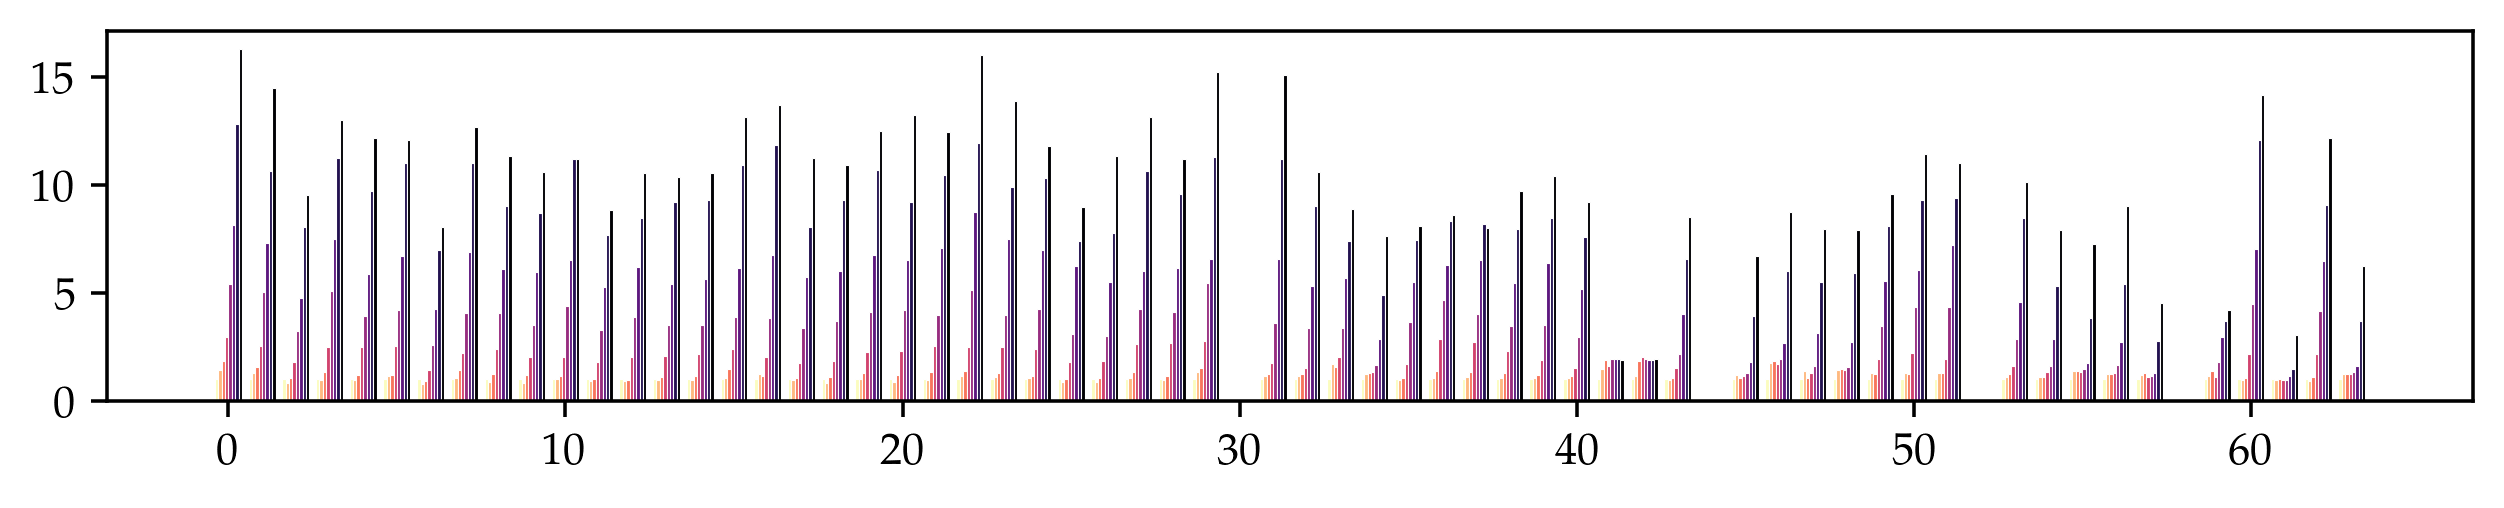

In [35]:
import matplotlib.pyplot as plt
import bokeh.palettes

colors = bokeh.palettes.magma(len(schemes))
colors = colors[::-1]

width = len(benchmarks) / 6.5
height = 1.5

bar_width = .1

SPACE_BETWEEN_SUITES = 1

fig, ax = plt.subplots(figsize=(width, height), dpi=320)

all_x_labels = []
all_x_labels_positions = []
x_start = 0
x_start -= bar_width * (len(schemes) - 1) / 2
for suite in range(len(suites)):
    benchmark_x_labels = suites[suite]['benchmarks']
    benchmark_x_labels_positions = np.arange(len(benchmark_x_labels), dtype=float)
    benchmark_x_labels_positions += x_start + bar_width * (len(schemes) - 1) / 2
    all_x_labels_positions += benchmark_x_labels_positions.tolist()
    xs = np.arange(len(benchmark_x_labels), dtype=float)
    xs += x_start
    for scheme in range(len(schemes)):
        ys = [benchmark_to_speedups[benchmark][scheme] for benchmark in benchmark_x_labels]
        ax.bar(xs, ys, bar_width, color=colors[scheme], edgecolor='white', linewidth=0.25)
        xs += bar_width
    x_start += len(benchmark_x_labels) + SPACE_BETWEEN_SUITES
    all_x_labels += benchmark_x_labels

# xlabel
ax.set_xticks(all_x_labels_positions, all_x_labels, rotation=45, fontsize=6, ha='right', rotation_mode='anchor',
              va='top', y=0.1)

# remove xticks
ax.tick_params(axis='x', which='both', bottom=False, top=False)

# x is log
ax.set_yscale('log')

y_ticks = [0.1, 1, 10, 50]
ax.set_ylim(y_ticks[0], y_ticks[-1])
ax.set_yticks(y_ticks[1:-1], [f'{tick}' for tick in y_ticks[1:-1]], fontsize=6, x=0.005)

# a horizontal line at y=1
ax.axhline(y=1, color='black', linewidth=0.25, linestyle='--', clip_on=False, alpha=0.5)

ax.set_ylabel('Speedup', fontsize=6)

plt.margins(x=0.002, y=0.1)

# grid major y
# ax.set_axisbelow(True)

# ax.grid(which='major', axis='y', linestyle='--', linewidth=0.25, color='black', zorder=-100)

# labels: =schemes[scheme]
for scheme in range(len(schemes)):
    ax.bar(0, 0, color=colors[scheme], label=f'{schemes[scheme]}', edgecolor='black', linewidth=0.25)

# legend is on top middle of the plot one row above the plot
plt.legend(loc='upper center',
           bbox_to_anchor=(0.5, 1.05),
           ncol=len(schemes),
           fontsize=5.5,
           frameon=False,
           edgecolor='black')

# make ticks thinner
ax.tick_params(which='both', width=0.25)

plt.tight_layout()

plt.savefig('out/compilation_latencies_comparison.impact_of_staggered_release.pdf', bbox_inches='tight', pad_inches=0.0,
            dpi=320, transparent=True,
            format='pdf')

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

with open('in/tmp.txt') as f:
    results = f.readlines()
    results = [result.strip() for result in results]
    results = [result for result in results if result]
    results = [json.loads(result) for result in results]
results = [np.mean(result['Latencies']) for result in results]
# print(results)
# benchmarks, len(benchmarks)

names = [0, 1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]
latencies = results
# make it relative to first
latencies = [latency / latencies[0] for latency in latencies]
speedups = [1. / latency for latency in latencies]
# print(speedups)

xs = np.arange(len(names))
plt.figure(figsize=(3, 1), dpi=320)
# plt.bar(xs, latencies, color='red', edgecolor='black', linewidth=0.25)
plt.plot(xs, speedups, marker='.', color='red', markersize=2, linewidth=0.5)

# write the value on top of the bar
for i, speedup in enumerate(speedups):
    plt.text(i, speedup, f'$\\times{speedup:.0f}$', ha='center', va='bottom', fontsize=6)

# y limit
plt.ylim(1, 22)

# y is log
# plt.yscale('log')

# remove y ticks
plt.yticks([])
# remove y minor ticks
plt.minorticks_off()

plt.xticks(xs, [f'{name}' for name in names], fontsize=6)

plt.xlabel('Staggered Release (ms)', fontsize=6)
plt.ylabel('Relative\nCompilation Speedup', fontsize=5)

# to pdf
plt.savefig('out/impact_or_staggered_release_on_latency.pdf',
            bbox_inches='tight',
            pad_inches=0.01,
            dpi=320,
            transparent=True,
            format='pdf')

plt.show()

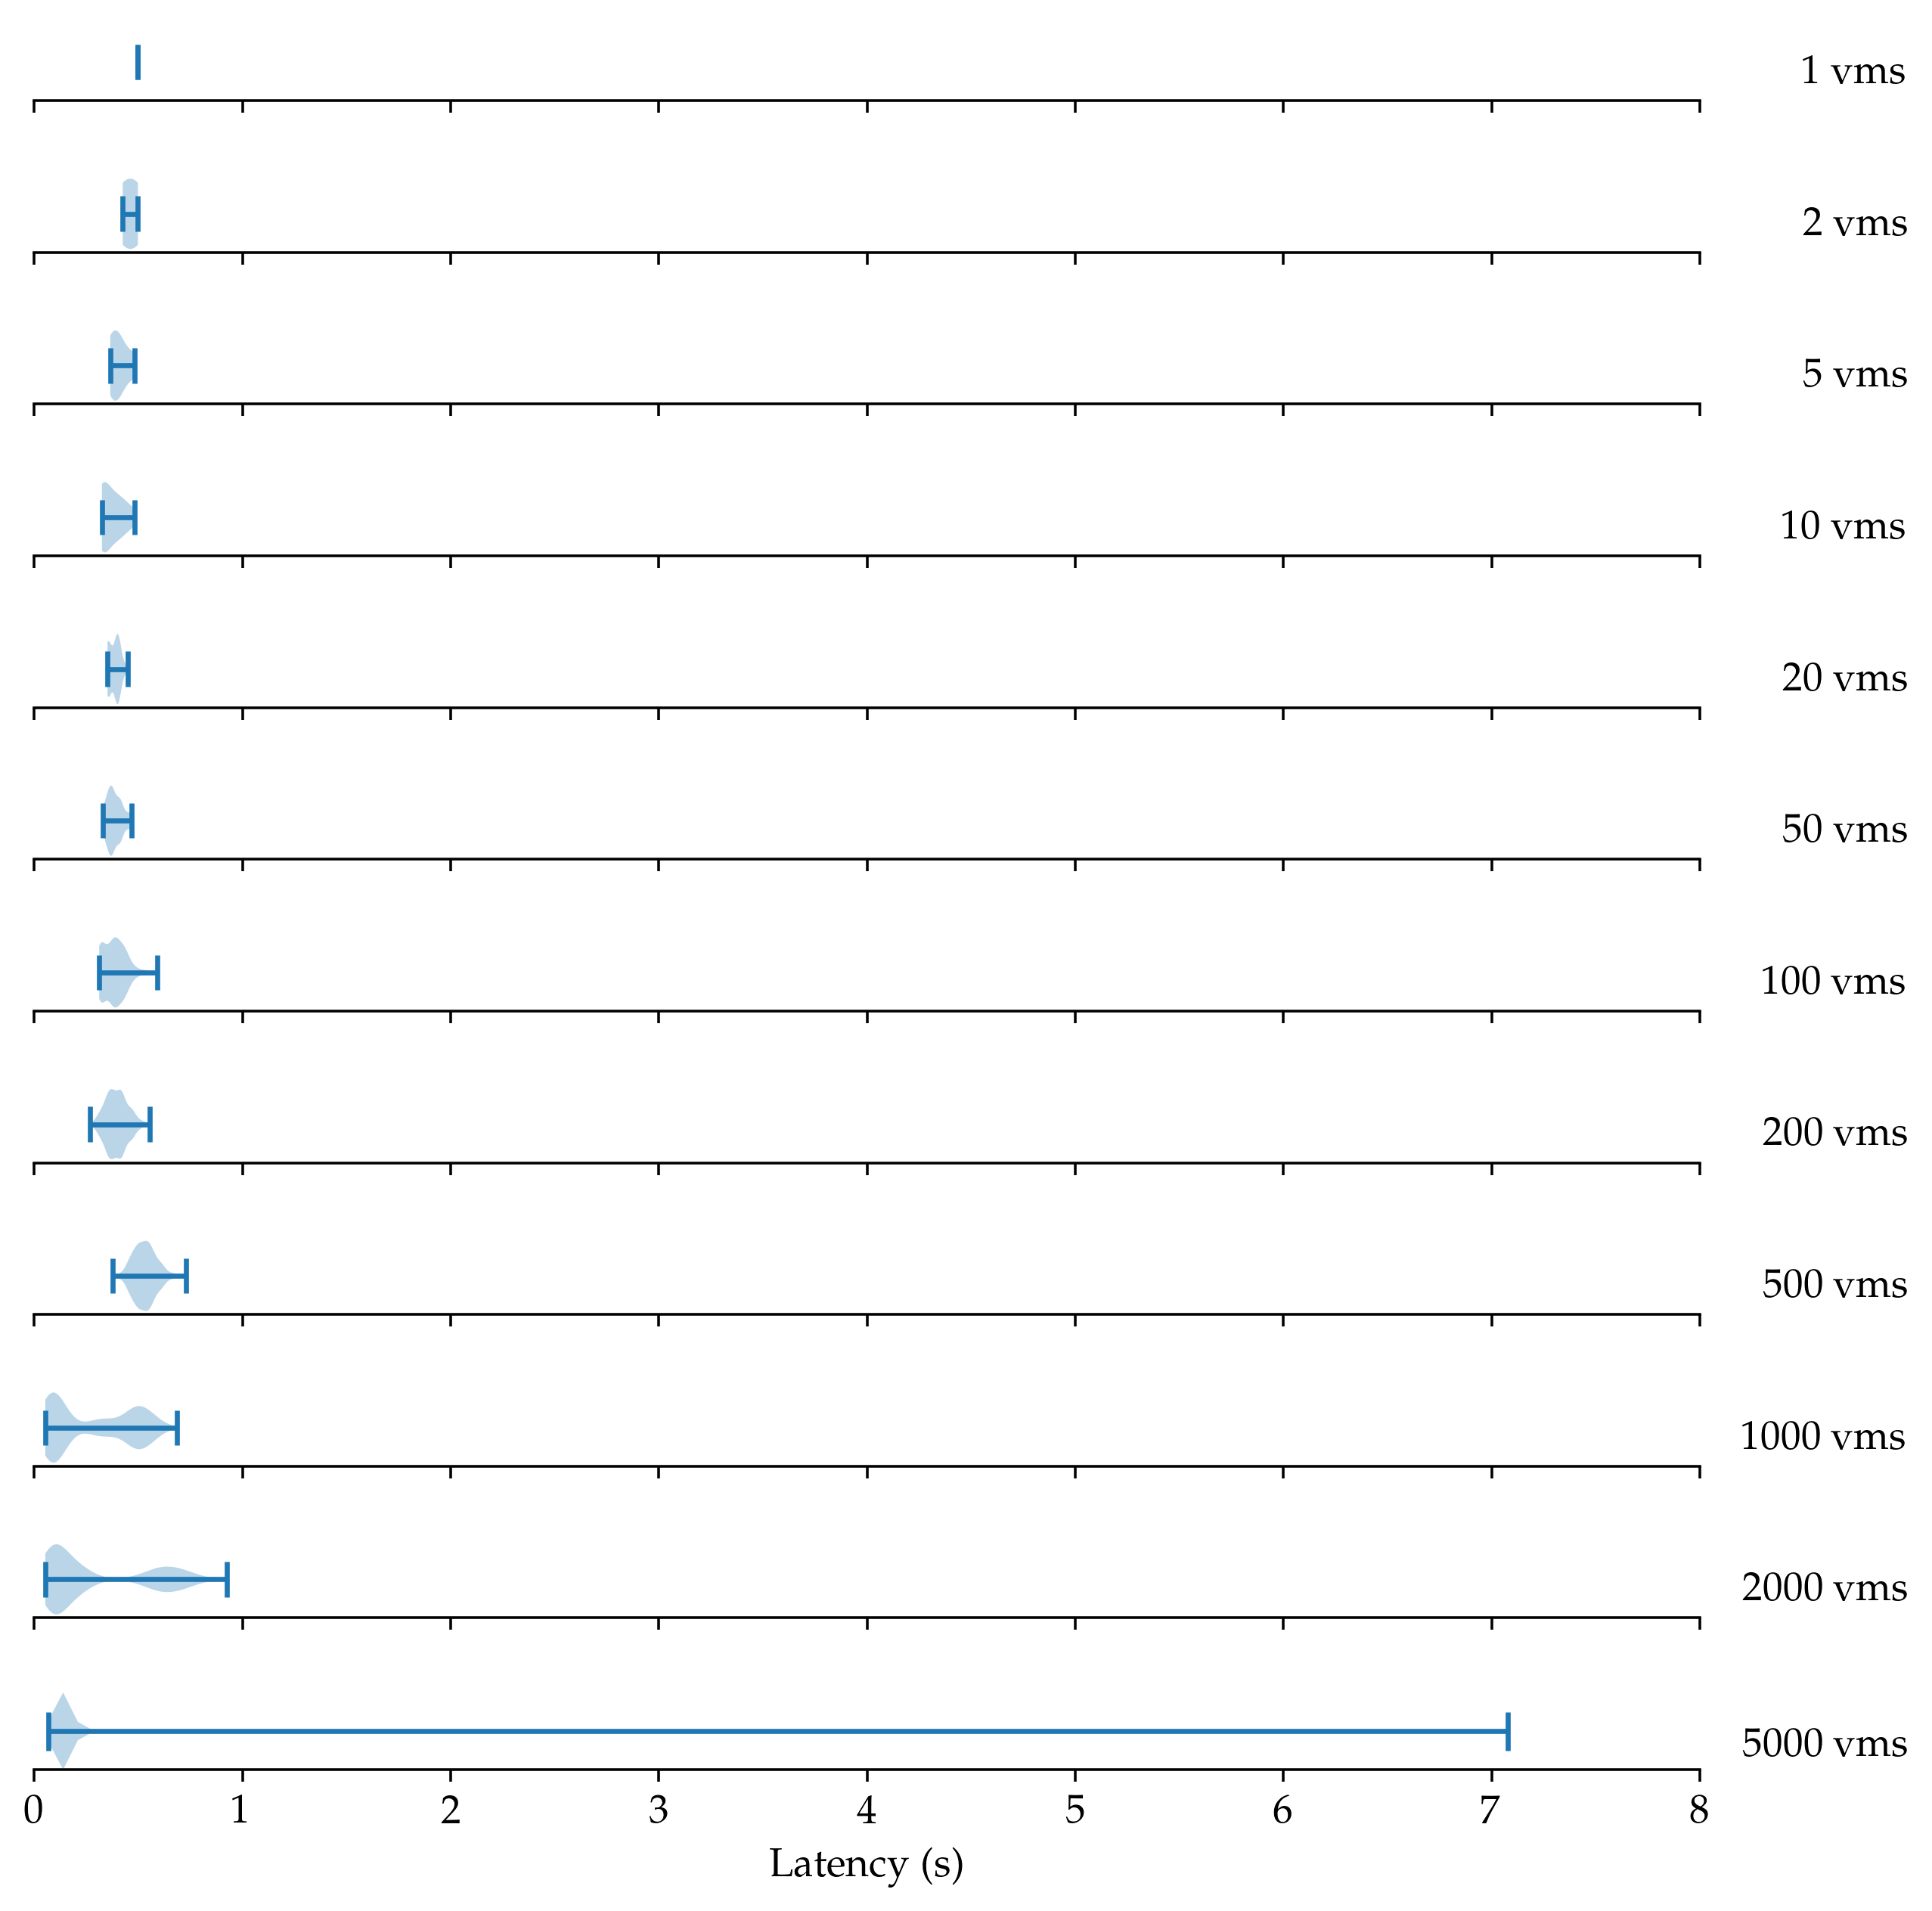

In [3]:
import json
import matplotlib.pyplot as plt

with open('in/num_of_workers.txt') as f:
    results = f.readlines()
    results = [result.strip() for result in results]
    results = [result for result in results if result]
    results = [json.loads(result) for result in results]
    workers = [result['NumberOfWorkers'] for result in results]

for i, worker in enumerate(workers):
    if workers[i] == 3790:
        workers[i] = 5000

# subplot
fig, axs = plt.subplots(len(results), 1, figsize=(8, 8), dpi=320, sharex=True)
# make subplots close to each other


for i, data in enumerate(results):
    jits = data['Latencies']
    jits = [jit / 1000 for jit in jits]
    e2es = data['E2Es']
    e2es = [e2e / 1000 for e2e in e2es]
    execs = data['Execs']
    execs = [exec / 1000 for exec in execs]

    # print avgs
    # print(f'jit={sum(jits) / len(jits):.2f} e2e={sum(e2es) / len(e2es):.2f} exec={sum(execs) / len(execs):.2f}')

    jit_max = max(jits)
    e2e_max = max(e2es)
    exec_max = max(execs)
    # print(f'jit_max={jit_max:.2f}')
    # print(f'jit_max={jit_max:.2f} e2e_max={max(e2es):.2f} exec_max={max(execs):.2f}')

    # violin plot same plot
    # axs[opt].figure(figsize=(20, 1), dpi=320)
    axs[i].violinplot(jits, showmeans=False, vert=False)
    # axs[opt].violinplot(e2es, showmeans=False, vert=False)
    # axs[opt].violinplot(execs, showmeans=False, vert=False)

    axs[i].text(9, .75, f'{workers[i]} vms\n', ha='right', va='center', fontsize=12)

    # remove spines
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].spines['left'].set_visible(False)

    # no y ticks
    axs[i].set_yticks([])

# x lim is 0 20
plt.xlim(0, 8)

# x ticks
plt.xticks([i for i in range(9)], [f'{i}' for i in range(9)], fontsize=12)

# set x title
plt.xlabel('Latency (s)', fontsize=12)

plt.margins(0.0)

plt.tight_layout()

plt.savefig('out/impact_of_num_of_workers_on_latency.pdf', bbox_inches='tight', pad_inches=0.01, dpi=320,
            transparent=True, format='pdf')

plt.show()

In [2]:
total_get_times = [result['TotalGetTime'] / result['NumberOfWorkers'] for result in results]
total_get_times

[381.0,
 272.5,
 238.4,
 242.7,
 235.7,
 197.22,
 162.97,
 132.395,
 69.752,
 25.682,
 15.355,
 2.4596306068601583]

In [3]:
total_get_times = [result['TotalGetTime'] for result in results]
total_get_times

[381, 545, 1192, 2427, 4714, 9861, 16297, 26479, 34876, 25682, 30710, 9322]

In [13]:
# violin plot "Latencies"
import json
import matplotlib.pyplot as plt

with open('in/num_of_workers.txt') as f:
    results = f.readlines()
    results = [result.strip() for result in results]
    results = [result for result in results if result]
    results = [json.loads(result) for result in results]
    workers = [result['NumberOfWorkers'] for result in results]

for i, data in enumerate(results):
    jits = data['Latencies']
    jits = [jit / 1000 for jit in jits]
    e2es = data['E2Es']
    e2es = [e2e / 1000 for e2e in e2es]
    execs = data['Execs']
    execs = [exec / 1000 for exec in execs]

    print(data['NumberOfWorkers'], max(jits))

1 0.496
2 0.498
5 0.481
10 0.483
20 0.451
50 0.468
100 0.592
200 0.554
500 0.73
1000 0.684
2000 0.924
3790 7.078


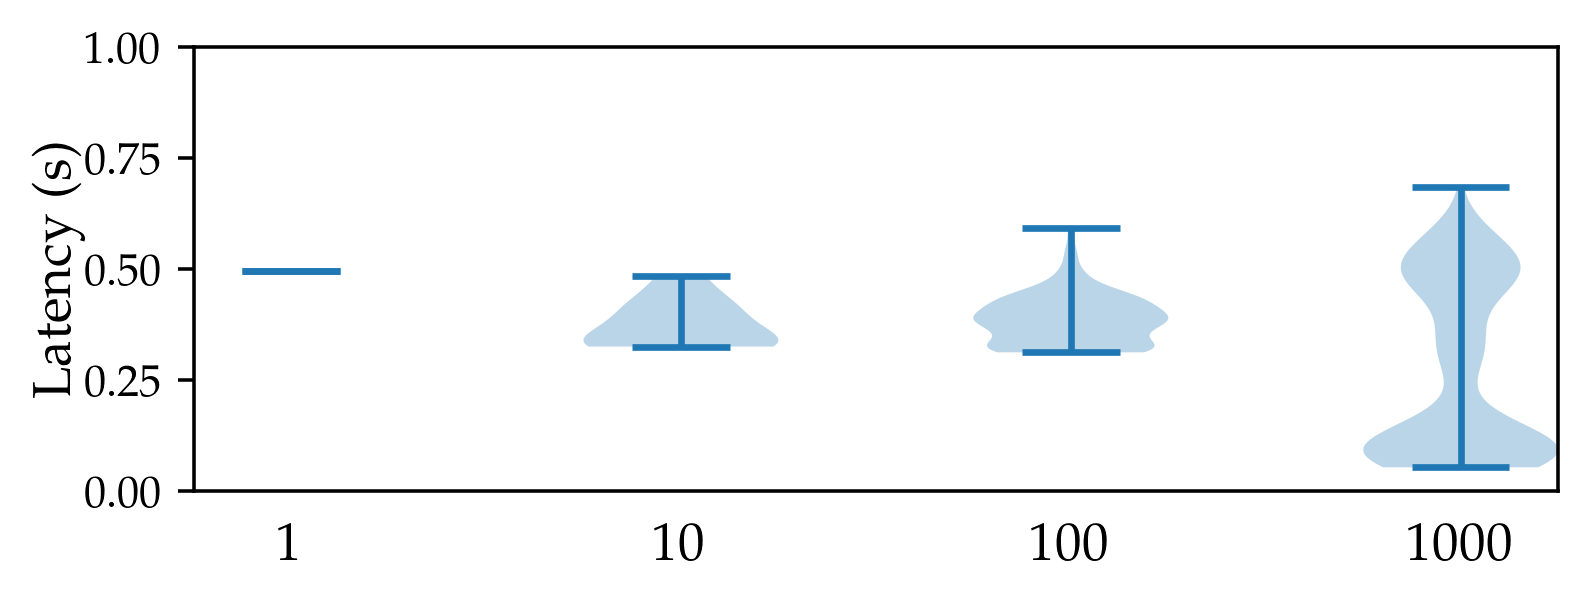

In [43]:
import json
import matplotlib.pyplot as plt
import numpy as np

with open('in/num_of_workers.txt') as f:
    results = f.readlines()
    results = [result.strip() for result in results]
    results = [result for result in results if result]
    results = [json.loads(result) for result in results]
    workers = [result['NumberOfWorkers'] for result in results]

data = []
for i, result in enumerate(results):
    if result['NumberOfWorkers'] not in [1, 10, 100, 1000]:
        continue

    record = {}
    jits = result['Latencies']
    jits = [jit / 1000 for jit in jits]
    e2es = result['E2Es']
    e2es = [e2e / 1000 for e2e in e2es]
    execs = result['Execs']
    execs = [exec / 1000 for exec in execs]

    record['num'] = result['NumberOfWorkers']
    record['jit'] = jits
    record['e2e'] = e2es
    record['exec'] = execs

    data.append(record)
data

data_to_plot = [data[i]['jit'] for i in range(len(data))]

# Create a figure instance
fig, ax = plt.subplots(figsize=(5, 2), dpi=320)

# Create the boxplot
ax.violinplot(data_to_plot, showmeans=False, vert=True, widths=0.5)


# x ticks are [1, 10, 100, 1000]
plt.xticks([i for i in range(1, 5)], [f'{data[i]["num"]}' for i in range(len(data))], fontsize=12)
ax.tick_params('x', width=0)

# y is latency
# y lim is 0 1
plt.ylim(0, 1)
# y label
plt.ylabel('Latency (s)', fontsize=12, labelpad=0)

ax.margins(0.0)

# tight layout
plt.tight_layout()

plt.savefig('out/impact_of_num_of_workers_on_latency.pdf', bbox_inches='tight', pad_inches=0.01, dpi=320,
            transparent=True, format='pdf')

plt.show()